### Parametres

In [8]:
from functools import partial
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import torch

import vt_all_solvers_wrapper as vt
import dataset
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(dataset)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

import base_range_library 
importlib.reload(base_range_library)
from base_range_library import range_library, hole_library, length_range_library

from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader
from utils import (
    DEFAULT_VALIDATION_METRICS,
    TrainConfig,
    fit,
    make_optimizer,
    mse_loss,
    plot_history,
)
from losses import UniversalTransferFunctionLoss
from models.mlp import ProfileMLP, webster_mlp_batch_to_xy
from models.fno import TransferFunctionFNO, webster_fno_batch_to_xy
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionFiLMDeepONet,
    TransferFunctionBilinearFusionDeepONet,
    TransferFunctionAttentionFusionDeepONet,
    TransferFunctionSIRENDeepONet,
    TransferFunctionMambaFusionDeepONet,
    TransferFunctionMambaSIRENDynamicDeformableDeepONet,
    TransferFunctionMambaOperator,
    TransferFunctionDynamicDeepONet,
    TransferFunctionDeformableDeepONet,
    webster_deeponet_batch_to_xy,
)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
mamba_operator_batch_size = 4
sections = 100
n_profile_points = 200
n_frequencies = 512

steps_per_epoch = 10
val_steps = 10
epochs = 40

# None disables live plotting during training.
live_plot_every_steps = 50

# Change this to inspect another channel inside the validation batch.
preview_sample_idx = 0

loss_name = "transfer_db"  # "mse" or "transfer_db"

transfer_loss_db_kwargs = {
    "output_type": "db",

    "db_weight": 1.0,
    "magnitude_weight": 0.1,
    "db_derivative_weight": 0.02,

    "peak_weight": 0.0,
    "peak_level_weight": 0.3,

    "complex_weight": 0.0,
    "complex_derivative_weight": 0.0,
    "phase_weight": 0.0,

    "db_error_scale": 10.0,
    "db_derivative_scale": 0.01,

    "peak_temperature_db": 3.0,
    "peak_min_prominence_db": 1.0,
    "peak_min_distance_hz": 40.0,
    "peak_max_count": None,

    "min_db": -100.0,
    "eps": 1e-8,
}

solver_config = vt.SolverConfig(
    solver="cone",
    sections=sections,
    points=n_frequencies,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
)

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=1,
)

val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=100_000,
    max_samples=batch_size * val_steps,
)

print("device:", device)


device: cuda


In [10]:
train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

val_loader = make_streaming_dataloader(
    val_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

In [11]:
mlp_batch_to_xy = partial(
    webster_mlp_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
)

fno_batch_to_xy = partial(
    webster_fno_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
)

deeponet_batch_to_xy = partial(
    webster_deeponet_batch_to_xy,
    n_points=n_profile_points,
    log_area=True,
    frequency_min_hz=solver_config.f_min_hz,
    frequency_max_hz=solver_config.f_max_hz,
)

In [12]:
# Validation metrics are often the slowest part of training.
# Use "fast" for training, "spectral" for peak/shape monitoring, "full" for diagnostics.
validation_metric_preset = "full"  # "fast", "spectral", "full", or "none"

FAST_VALIDATION_METRICS = [
    "mae",
    "rmse",
    "rel_l2",
]

SPECTRAL_VALIDATION_METRICS = [
    "mae",
    "rmse",
    "rel_l2",
    "relative_derivative_l2",
    "dominant_peak_level_mae_db",
    "dominant_notch_level_mae_db",
]

if validation_metric_preset == "fast":
    validation_metrics = FAST_VALIDATION_METRICS
elif validation_metric_preset == "spectral":
    validation_metrics = SPECTRAL_VALIDATION_METRICS
elif validation_metric_preset == "full":
    validation_metrics = list(DEFAULT_VALIDATION_METRICS.keys())
elif validation_metric_preset == "none":
    validation_metrics = []
else:
    raise ValueError("validation_metric_preset must be 'fast', 'spectral', 'full', or 'none'")

transfer_loss_db = UniversalTransferFunctionLoss(**transfer_loss_db_kwargs)

loss_registry = {
    "mse": mse_loss,
    "transfer_db": transfer_loss_db,
}

criterion = loss_registry[loss_name]


def make_plateau_scheduler(
    optimizer,
    *,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=factor,
        patience=patience,
        min_lr=min_lr,
    )


print("loss:", criterion)
print("validation metric preset:", validation_metric_preset)
print("validation metrics:", validation_metrics)



loss: UniversalTransferFunctionLoss()
validation metric preset: full
validation metrics: ['mae', 'rmse', 'rel_l2', 'magnitude_mae_db', 'magnitude_rmse_db', 'magnitude_max_abs_error_db', 'relative_derivative_l2', 'dominant_peak_frequency_mae_hz', 'dominant_peak_level_mae_db', 'dominant_notch_frequency_mae_hz', 'dominant_notch_level_mae_db', 'relative_complex_l2_percent', 'phase_mae_degrees']


In [13]:
validation_preview_batch = lambda: utils.validation_preview_batch(val_loader)
predict_on_batch = lambda model, batch_to_xy, batch: utils.predict_on_batch(
    model,
    batch_to_xy,
    batch,
    device=device,
)
batch_geometry_to_explicit = utils.batch_geometry_to_explicit
plot_batch_geometry = utils.plot_batch_geometry
plot_model_prediction_on_channel = utils.plot_model_prediction_on_channel


def cleanup_training_memory(*, keep_model_names=()):
    keep_model_names = set(keep_model_names)

    keep_model_names.update({"criterion", "transfer_loss_db"})

    for name, value in list(globals().items()):
        if name in keep_model_names:
            continue
        if isinstance(value, torch.nn.Module):
            value.to("cpu")

    for name in list(globals()):
        if name.endswith("_optimizer") or name.endswith("_scheduler"):
            globals().pop(name, None)

    if plt is not None:
        plt.close("all")

    import gc
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except RuntimeError:
            pass




### MLP

In [ ]:
cleanup_training_memory()

print("=== Training MLP ===")
mlp_checkpoint_name = "mlp_db"

mlp = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
    hidden_dim=512,
    depth=4,
    dropout=0.05,
    out_channels=1,
).to(device)

mlp_optimizer = utils.make_optimizer(
    mlp,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_scheduler = utils.make_plateau_scheduler(
    mlp_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

mlp_history = utils.fit(
    mlp,
    mlp_optimizer,
    train_loader,
    val_loader,
    scheduler=mlp_scheduler,
    criterion=criterion,
    batch_to_xy=mlp_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=mlp_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(mlp_history)






#### Проверка MLP на одном канале

In [ ]:
utils.plot_single_model_preview(
    mlp,
    mlp_batch_to_xy,
    "MLP",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### MLP MSE baseline


In [ ]:
cleanup_training_memory()

print("=== Training MLP MSE baseline ===")
mlp_mse_checkpoint_name = "mlp_mse_db"

mlp_mse = ProfileMLP(
    n_profile_points=n_profile_points,
    in_channels=2,  # log(area), x
    n_frequencies=n_frequencies,
    hidden_dim=512,
    depth=4,
    dropout=0.05,
    out_channels=1,
).to(device)

mlp_mse_optimizer = utils.make_optimizer(
    mlp_mse,
    lr=1e-3,
    weight_decay=1e-4,
)

mlp_mse_scheduler = utils.make_plateau_scheduler(
    mlp_mse_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

mlp_mse_history = utils.fit(
    mlp_mse,
    mlp_mse_optimizer,
    train_loader,
    val_loader,
    scheduler=mlp_mse_scheduler,
    criterion=utils.mse_loss,
    batch_to_xy=mlp_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=mlp_mse_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(mlp_mse_history)


#### Проверка MLP MSE baseline на одном канале


In [ ]:
utils.plot_single_model_preview(
    mlp_mse,
    mlp_batch_to_xy,
    "MLP MSE baseline",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### FNO

In [ ]:
cleanup_training_memory()

print("=== Training FNO ===")
fno_checkpoint_name = "fno_db"

fno = TransferFunctionFNO(
    n_modes=32,
    hidden_channels=96,
    latent_dim=256,
    pooling_bins=16,
    frequency_bands=16,
    out_channels=1,
).to(device)

fno_optimizer = utils.make_optimizer(
    fno,
    lr=5e-4,
    weight_decay=1e-4,
)

fno_scheduler = utils.make_plateau_scheduler(
    fno_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

fno_history = utils.fit(
    fno,
    fno_optimizer,
    train_loader,
    val_loader,
    scheduler=fno_scheduler,
    criterion=criterion,
    batch_to_xy=fno_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=fno_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(fno_history)






#### Проверка FNO на одном канале

In [ ]:
utils.plot_single_model_preview(
    fno,
    fno_batch_to_xy,
    "FNO",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

### DeepONet

In [ ]:
cleanup_training_memory()

print("=== Training DeepONet ===")
deeponet_checkpoint_name = "deeponet_db"

deeponet = TransferFunctionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
).to(device)

deeponet_optimizer = utils.make_optimizer(
    deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

deeponet_scheduler = utils.make_plateau_scheduler(
    deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

deeponet_history = utils.fit(
    deeponet,
    deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(deeponet_history)

#### Проверка DeepONet на одном канале

In [ ]:
utils.plot_single_model_preview(
    deeponet,
    deeponet_batch_to_xy,
    "DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=10,
)

### FiLM DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training FiLM DeepONet ===")
film_deeponet_checkpoint_name = "film_deeponet_db"

film_deeponet = TransferFunctionFiLMDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
).to(device)

film_deeponet_optimizer = utils.make_optimizer(
    film_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

film_deeponet_scheduler = utils.make_plateau_scheduler(
    film_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

film_deeponet_history = utils.fit(
    film_deeponet,
    film_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=film_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=film_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(film_deeponet_history)


#### Проверка FiLM DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    film_deeponet,
    deeponet_batch_to_xy,
    "FiLM DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### Bilinear Fusion DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training Bilinear Fusion DeepONet ===")
bilinear_fusion_deeponet_checkpoint_name = "bilinear_fusion_deeponet_db"

bilinear_fusion_deeponet = TransferFunctionBilinearFusionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    fusion_rank=128,
    out_channels=1,
    residual_dot=True,
).to(device)

bilinear_fusion_deeponet_optimizer = utils.make_optimizer(
    bilinear_fusion_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

bilinear_fusion_deeponet_scheduler = utils.make_plateau_scheduler(
    bilinear_fusion_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

bilinear_fusion_deeponet_history = utils.fit(
    bilinear_fusion_deeponet,
    bilinear_fusion_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=bilinear_fusion_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=bilinear_fusion_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(bilinear_fusion_deeponet_history)


#### Проверка Bilinear Fusion DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    bilinear_fusion_deeponet,
    deeponet_batch_to_xy,
    "Bilinear Fusion DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### Attention Fusion DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training Attention Fusion DeepONet ===")
attention_fusion_deeponet_checkpoint_name = "attention_fusion_deeponet_db"

attention_fusion_deeponet = TransferFunctionAttentionFusionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    attention_dim=64,
    memory_tokens=8,
    out_channels=1,
    dropout=0.0,
    residual_dot=True,
).to(device)

attention_fusion_deeponet_optimizer = utils.make_optimizer(
    attention_fusion_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

attention_fusion_deeponet_scheduler = utils.make_plateau_scheduler(
    attention_fusion_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

attention_fusion_deeponet_history = utils.fit(
    attention_fusion_deeponet,
    attention_fusion_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=attention_fusion_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=attention_fusion_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(attention_fusion_deeponet_history)


#### Проверка Attention Fusion DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    attention_fusion_deeponet,
    deeponet_batch_to_xy,
    "Attention Fusion DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### SIREN DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training SIREN DeepONet ===")
siren_deeponet_checkpoint_name = "siren_deeponet_db"

siren_deeponet = TransferFunctionSIRENDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    trunk_hidden_dim=128,
    trunk_hidden_layers=3,
    first_omega_0=10.0,
    hidden_omega_0=10.0,
    out_channels=1,
).to(device)

siren_deeponet_optimizer = utils.make_optimizer(
    siren_deeponet,
    lr=5e-2,
    weight_decay=1e-4,
)

siren_deeponet_scheduler = utils.make_plateau_scheduler(
    siren_deeponet_optimizer,
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

siren_deeponet_history = utils.fit(
    siren_deeponet,
    siren_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=siren_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=siren_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(siren_deeponet_history)

#### Проверка SIREN DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    siren_deeponet,
    deeponet_batch_to_xy,
    "SIREN DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

### Mamba Fusion DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training Mamba Fusion DeepONet ===")
mamba_fusion_deeponet_checkpoint_name = "mamba_fusion_deeponet_db"

mamba_fusion_deeponet = TransferFunctionMambaFusionDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    mamba_backend="minimal_mamba2",
    mamba_depth=1,
    mamba_expansion=2,
    mamba_kernel_size=4,
    mamba_d_state=32,
    mamba_headdim=32,
    mamba_chunk_size=64,
    dropout=0.0,
    residual_dot=True,
).to(device)

mamba_fusion_deeponet_optimizer = utils.make_optimizer(
    mamba_fusion_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

mamba_fusion_deeponet_scheduler = utils.make_plateau_scheduler(
    mamba_fusion_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

mamba_fusion_deeponet_history = utils.fit(
    mamba_fusion_deeponet,
    mamba_fusion_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=mamba_fusion_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=mamba_fusion_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(mamba_fusion_deeponet_history)

#### Проверка Mamba Fusion DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    mamba_fusion_deeponet,
    deeponet_batch_to_xy,
    "Mamba Fusion DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

### Mamba SIREN Dynamic Deformable DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training Mamba SIREN Dynamic Deformable DeepONet ===")
mamba_siren_dynamic_deformable_deeponet_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_db"

# Set any donor checkpoint to None to initialize that block from scratch.
# You can pass either checkpoint stems or full .pt paths.
warm_start_mamba_fusion_checkpoint = "mamba_fusion_deeponet_db"  # "mamba_fusion_deeponet_db"
warm_start_siren_checkpoint = "siren_deeponet_db"  # "siren_deeponet_db"
warm_start_dynamic_checkpoint = "dynamic_deeponet_new_db"  # "dynamic_deeponet_new_db"
warm_start_deformable_checkpoint = "deformable_deeponet_db"  # "deformable_deeponet_db"

mamba_siren_dynamic_deformable_deeponet = TransferFunctionMambaSIRENDynamicDeformableDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    trunk_hidden_dim=128,
    trunk_hidden_layers=3,
    first_omega_0=10.0,
    hidden_omega_0=10.0,
    out_channels=1,
    n_experts=4,
    routing_hidden_dim=32,
    temperature=1.0,
    max_offset=2.0,
    offset_hidden_channels=32,
    mamba_backend="minimal_mamba2",
    mamba_depth=1,
    mamba_expansion=2,
    mamba_kernel_size=4,
    mamba_d_state=32,
    mamba_headdim=32,
    mamba_chunk_size=64,
    dropout=0.0,
    residual_dot=True,
    warm_start_mamba_fusion_checkpoint=warm_start_mamba_fusion_checkpoint,
    warm_start_siren_checkpoint=warm_start_siren_checkpoint,
    warm_start_dynamic_checkpoint=warm_start_dynamic_checkpoint,
    warm_start_deformable_checkpoint=warm_start_deformable_checkpoint,
    warm_start_checkpoint_dir="checkpoints",
    warm_start_map_location="cpu",
    warm_start_verbose=True,
).to(device)

mamba_siren_dynamic_deformable_deeponet_optimizer = utils.make_optimizer(
    mamba_siren_dynamic_deformable_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

mamba_siren_dynamic_deformable_deeponet_scheduler = utils.make_plateau_scheduler(
    mamba_siren_dynamic_deformable_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

mamba_siren_dynamic_deformable_deeponet_history = utils.fit(
    mamba_siren_dynamic_deformable_deeponet,
    mamba_siren_dynamic_deformable_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=mamba_siren_dynamic_deformable_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=mamba_siren_dynamic_deformable_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(mamba_siren_dynamic_deformable_deeponet_history)


#### Проверка Mamba SIREN Dynamic Deformable DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    mamba_siren_dynamic_deformable_deeponet,
    deeponet_batch_to_xy,
    "Mamba SIREN Dynamic Deformable DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)


### Mamba Operator


In [ ]:
cleanup_training_memory()

print("=== Training Mamba Operator ===")
mamba_operator_checkpoint_name = "mamba_operator_db"

mamba_operator_val_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    solver_config=solver_config,
    target_mode="db",
    seed=100_000,
    max_samples=mamba_operator_batch_size * val_steps,
)

mamba_operator_train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=mamba_operator_batch_size,
    num_workers=0,
)

mamba_operator_val_loader = make_streaming_dataloader(
    mamba_operator_val_config,
    range_library,
    batch_size=mamba_operator_batch_size,
    num_workers=0,
)


mamba_operator = TransferFunctionMambaOperator(
    in_channels=1,
    d_model=32,
    hidden_channels=64,
    frequency_bands=16,
    frequency_hidden_dim=128,
    mamba_backend="minimal_mamba2",
    mamba_depth=2,
    mamba_expansion=2,
    mamba_kernel_size=4,
    mamba_d_state=16,
    mamba_headdim=32,
    mamba_chunk_size=32,
    dropout=0.0,
    out_channels=1,
    frequency_chunk_size=8,
).to(device)

mamba_operator_optimizer = utils.make_optimizer(
    mamba_operator,
    lr=5e-4,
    weight_decay=1e-4,
)

mamba_operator_scheduler = utils.make_plateau_scheduler(
    mamba_operator_optimizer,
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

mamba_operator_history = utils.fit(
    mamba_operator,
    mamba_operator_optimizer,
    mamba_operator_train_loader,
    mamba_operator_val_loader,
    scheduler=mamba_operator_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=mamba_operator_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(mamba_operator_history)

#### Проверка Mamba Operator на одном канале


In [ ]:
utils.plot_single_model_preview(
    mamba_operator,
    deeponet_batch_to_xy,
    "Mamba Operator",
    loader=mamba_operator_val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

### Dynamic DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training Dynamic DeepONet ===")
dynamic_deeponet_checkpoint_name = "dynamic_deeponet_new_db"

dynamic_deeponet = TransferFunctionDynamicDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    n_experts=4,
    routing_hidden_dim=32,
    temperature=1.0,
).to(device)

dynamic_deeponet_optimizer = utils.make_optimizer(
    dynamic_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

dynamic_deeponet_scheduler = utils.make_plateau_scheduler(
    dynamic_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

dynamic_deeponet_history = utils.fit(
    dynamic_deeponet,
    dynamic_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=dynamic_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=dynamic_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(dynamic_deeponet_history)


In [ ]:
# Plot selected validation metrics from a saved checkpoint

metrics_checkpoint_name = "dynamic_deeponet_new_db"
metrics_normalize = True

history = utils.load_history_from_checkpoint(
    metrics_checkpoint_name,
    checkpoint_dir="checkpoints",
    map_location="cpu",
)

history_data = utils.history_to_mapping(history)
all_metric_names = sorted((history_data.get("metrics") or {}).keys())

metric_names = [
    name
    for name in all_metric_names
    if not name.endswith("_frequency_mae_hz")
]

print("checkpoint:", metrics_checkpoint_name)
print("metrics:", metric_names)

utils.plot_selected_metrics(
    history,
    metric_names,
    title=f"{metrics_checkpoint_name}: selected validation metrics",
    normalize=metrics_normalize,
)

#### Проверка Dynamic DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    dynamic_deeponet,
    deeponet_batch_to_xy,
    "Dynamic DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=1,
)
utils.plot_single_model_preview(
    dynamic_deeponet,
    deeponet_batch_to_xy,
    "Dynamic DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=3,
)

### Deformable DeepONet


In [ ]:
cleanup_training_memory()

print("=== Training Deformable DeepONet ===")
deformable_deeponet_checkpoint_name = "deformable_deeponet_db"

deformable_deeponet = TransferFunctionDeformableDeepONet(
    in_channels=1,
    hidden_channels=64,
    basis_dim=128,
    pooling_bins=16,
    frequency_bands=16,
    trunk_hidden_dim=128,
    out_channels=1,
    max_offset=2.0,
    offset_hidden_channels=32,
).to(device)

deformable_deeponet_optimizer = utils.make_optimizer(
    deformable_deeponet,
    lr=5e-4,
    weight_decay=1e-4,
)

deformable_deeponet_scheduler = utils.make_plateau_scheduler(
    deformable_deeponet_optimizer,
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

deformable_deeponet_history = utils.fit(
    deformable_deeponet,
    deformable_deeponet_optimizer,
    train_loader,
    val_loader,
    scheduler=deformable_deeponet_scheduler,
    criterion=criterion,
    batch_to_xy=deeponet_batch_to_xy,
    config=utils.TrainConfig(
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        device=device,
        show_progress=False,
        live_plot_every_steps=live_plot_every_steps,
        grad_clip_norm=None,
        checkpoint_name=deformable_deeponet_checkpoint_name,
        save_every_steps=None,
        validation_metrics=validation_metrics,
        scheduler_on="val_loss",
    ),
)

utils.plot_history(deformable_deeponet_history)




#### Проверка Deformable DeepONet на одном канале


In [ ]:
utils.plot_single_model_preview(
    deformable_deeponet,
    deeponet_batch_to_xy,
    "Deformable DeepONet",
    loader=val_loader,
    device=device,
    sample_idx=preview_sample_idx,
)

In [ ]:
run_finetune = False
run_hole_finetune = False
run_unexpected_geometry_check = False
run_scaling_check = False
run_geometry_sensitivity_check = False
run_frequency_grid_check = False

print("fine-tuning enabled:", run_finetune)
print("hole fine-tuning enabled:", run_hole_finetune)
print("optional diagnostics enabled:", {
    "unexpected_geometry": run_unexpected_geometry_check,
    "scaling": run_scaling_check,
    "geometry_sensitivity": run_geometry_sensitivity_check,
    "frequency_grid": run_frequency_grid_check,
})


### Дообучение


In [ ]:
if globals().get("run_finetune", False):
    cleanup_training_memory()

    importlib.reload(utils)

    finetune_model_name = "mamba_siren_dynamic_deformable_deeponet"  # "mlp", "mlp_mse", "fno", "deeponet", "film_deeponet", "bilinear_fusion_deeponet", "attention_fusion_deeponet", "siren_deeponet", "mamba_fusion_deeponet", "mamba_siren_dynamic_deformable_deeponet", "mamba_operator", "dynamic_deeponet", or "deformable_deeponet"
    finetune_epochs = 5
    finetune_steps_per_epoch = steps_per_epoch
    finetune_val_steps = val_steps
    finetune_batch_size = mamba_operator_batch_size if finetune_model_name == "mamba_operator" else batch_size
    finetune_lr_scale = 5e-4
    finetune_resume_optimizer = True
    finetune_live_plot_every_steps = 50
    finetune_save_every_steps = None
    finetune_checkpoint_suffix = "_finetuned"  # use "_finetuned" to keep the old best checkpoint untouched

    mlp_checkpoint_name = "mlp_db"
    mlp_mse_checkpoint_name = "mlp_mse_db"
    fno_checkpoint_name = "fno_db"
    deeponet_checkpoint_name = "deeponet_db"
    dynamic_deeponet_checkpoint_name = "dynamic_deeponet_new_db"
    deformable_deeponet_checkpoint_name = "deformable_deeponet_db"
    siren_deeponet_checkpoint_name = "siren_deeponet_db"
    film_deeponet_checkpoint_name = "film_deeponet_db"
    bilinear_fusion_deeponet_checkpoint_name = "bilinear_fusion_deeponet_db"
    attention_fusion_deeponet_checkpoint_name = "attention_fusion_deeponet_db"
    mamba_fusion_deeponet_checkpoint_name = "mamba_fusion_deeponet_db"
    mamba_siren_dynamic_deformable_deeponet_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_db"
    mamba_operator_checkpoint_name = "mamba_operator_db"

    active_library_kinds = [name for name in range_library.keys() if name != "random"]
    print("active library geometry kinds:", active_library_kinds)

    all_library_train_config = StreamingGeometryDatasetConfig(
        geometry_kind="random",  # random means: sample from every active key in range_library
        solver_config=solver_config,
        target_mode="db",
        seed=1_000_000,
    )

    all_library_val_config = StreamingGeometryDatasetConfig(
        geometry_kind="random",
        solver_config=solver_config,
        target_mode="db",
        seed=2_000_000,
        max_samples=finetune_batch_size * finetune_val_steps,
    )

    all_library_train_loader = make_streaming_dataloader(
        all_library_train_config,
        range_library,
        batch_size=finetune_batch_size,
        num_workers=0,
    )

    all_library_val_loader = make_streaming_dataloader(
        all_library_val_config,
        range_library,
        batch_size=finetune_batch_size,
        num_workers=0,
    )



    def make_mlp_for_finetune():
        return ProfileMLP(
            n_profile_points=n_profile_points,
            in_channels=2,
            n_frequencies=n_frequencies,
            hidden_dim=512,
            depth=4,
            dropout=0.05,
            out_channels=1,
        )


    def make_mlp_mse_for_finetune():
        return ProfileMLP(
            n_profile_points=n_profile_points,
            in_channels=2,
            n_frequencies=n_frequencies,
            hidden_dim=512,
            depth=4,
            dropout=0.05,
            out_channels=1,
        )


    def make_fno_for_finetune():
        return TransferFunctionFNO(
            n_modes=32,
            hidden_channels=96,
            latent_dim=256,
            pooling_bins=16,
            frequency_bands=16,
            out_channels=1,
        )


    def make_deeponet_for_finetune():
        return TransferFunctionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
        )


    def make_film_deeponet_for_finetune():
        return TransferFunctionFiLMDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
        )


    def make_bilinear_fusion_deeponet_for_finetune():
        return TransferFunctionBilinearFusionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            fusion_rank=128,
            out_channels=1,
            residual_dot=True,
        )


    def make_attention_fusion_deeponet_for_finetune():
        return TransferFunctionAttentionFusionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            attention_dim=64,
            memory_tokens=8,
            out_channels=1,
            dropout=0.0,
            residual_dot=True,
        )


    def make_siren_deeponet_for_finetune():
        return TransferFunctionSIRENDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            trunk_hidden_dim=128,
            trunk_hidden_layers=3,
            first_omega_0=10.0,
            hidden_omega_0=10.0,
            out_channels=1,
        )


    def make_mamba_fusion_deeponet_for_finetune():
        return TransferFunctionMambaFusionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            mamba_backend="minimal_mamba2",
            mamba_depth=1,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=32,
            mamba_headdim=32,
            mamba_chunk_size=64,
            dropout=0.0,
            residual_dot=True,
        )


    def make_mamba_siren_dynamic_deformable_deeponet_for_finetune():
        return TransferFunctionMambaSIRENDynamicDeformableDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            trunk_hidden_dim=128,
            trunk_hidden_layers=3,
            first_omega_0=10.0,
            hidden_omega_0=10.0,
            out_channels=1,
            n_experts=4,
            routing_hidden_dim=32,
            temperature=1.0,
            max_offset=2.0,
            offset_hidden_channels=32,
            mamba_backend="minimal_mamba2",
            mamba_depth=1,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=32,
            mamba_headdim=32,
            mamba_chunk_size=64,
            dropout=0.0,
            residual_dot=True,
        )


    def make_mamba_operator_for_finetune():
        return TransferFunctionMambaOperator(
            in_channels=1,
            d_model=32,
            hidden_channels=64,
            frequency_bands=16,
            frequency_hidden_dim=128,
            mamba_backend="minimal_mamba2",
            mamba_depth=2,
            mamba_expansion=2,
            mamba_kernel_size=4,
            mamba_d_state=16,
            mamba_headdim=32,
            mamba_chunk_size=32,
            dropout=0.0,
            out_channels=1,
            frequency_chunk_size=8,
        )


    def make_dynamic_deeponet_for_finetune():
        return TransferFunctionDynamicDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            n_experts=4,
            routing_hidden_dim=32,
            temperature=1.0,
        )


    def make_deformable_deeponet_for_finetune():
        return TransferFunctionDeformableDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            max_offset=2.0,
            offset_hidden_channels=32,
        )


    finetune_specs = {
        "mlp": {
            "variable_name": "mlp",
            "history_name": "mlp_history",
            "checkpoint_name": mlp_checkpoint_name,
            "factory": make_mlp_for_finetune,
            "batch_to_xy": mlp_batch_to_xy,
            "base_lr": 1e-3,
            "weight_decay": 1e-4,
            "label": "MLP",
        },
        "mlp_mse": {
            "variable_name": "mlp_mse",
            "history_name": "mlp_mse_history",
            "checkpoint_name": mlp_mse_checkpoint_name,
            "factory": make_mlp_mse_for_finetune,
            "batch_to_xy": mlp_batch_to_xy,
            "base_lr": 1e-3,
            "weight_decay": 1e-4,
            "label": "MLP MSE baseline",
            "criterion": utils.mse_loss,
        },
        "fno": {
            "variable_name": "fno",
            "history_name": "fno_history",
            "checkpoint_name": fno_checkpoint_name,
            "factory": make_fno_for_finetune,
            "batch_to_xy": fno_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "FNO",
        },
        "deeponet": {
            "variable_name": "deeponet",
            "history_name": "deeponet_history",
            "checkpoint_name": deeponet_checkpoint_name,
            "factory": make_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "DeepONet",
        },
        "film_deeponet": {
            "variable_name": "film_deeponet",
            "history_name": "film_deeponet_history",
            "checkpoint_name": film_deeponet_checkpoint_name,
            "factory": make_film_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "FiLM DeepONet",
        },
        "bilinear_fusion_deeponet": {
            "variable_name": "bilinear_fusion_deeponet",
            "history_name": "bilinear_fusion_deeponet_history",
            "checkpoint_name": bilinear_fusion_deeponet_checkpoint_name,
            "factory": make_bilinear_fusion_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Bilinear Fusion DeepONet",
        },
        "attention_fusion_deeponet": {
            "variable_name": "attention_fusion_deeponet",
            "history_name": "attention_fusion_deeponet_history",
            "checkpoint_name": attention_fusion_deeponet_checkpoint_name,
            "factory": make_attention_fusion_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Attention Fusion DeepONet",
        },
        "siren_deeponet": {
            "variable_name": "siren_deeponet",
            "history_name": "siren_deeponet_history",
            "checkpoint_name": siren_deeponet_checkpoint_name,
            "factory": make_siren_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "SIREN DeepONet",
        },
        "mamba_fusion_deeponet": {
            "variable_name": "mamba_fusion_deeponet",
            "history_name": "mamba_fusion_deeponet_history",
            "checkpoint_name": mamba_fusion_deeponet_checkpoint_name,
            "factory": make_mamba_fusion_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Mamba Fusion DeepONet",
        },

        "mamba_siren_dynamic_deformable_deeponet": {
            "variable_name": "mamba_siren_dynamic_deformable_deeponet",
            "history_name": "mamba_siren_dynamic_deformable_deeponet_history",
            "checkpoint_name": mamba_siren_dynamic_deformable_deeponet_checkpoint_name,
            "factory": make_mamba_siren_dynamic_deformable_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Mamba SIREN Dynamic Deformable DeepONet",
        },
        "mamba_operator": {
            "variable_name": "mamba_operator",
            "history_name": "mamba_operator_history",
            "checkpoint_name": mamba_operator_checkpoint_name,
            "factory": make_mamba_operator_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Mamba Operator",
        },
        "dynamic_deeponet": {
            "variable_name": "dynamic_deeponet",
            "history_name": "dynamic_deeponet_history",
            "checkpoint_name": dynamic_deeponet_checkpoint_name,
            "factory": make_dynamic_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Dynamic DeepONet",
        },
        "deformable_deeponet": {
            "variable_name": "deformable_deeponet",
            "history_name": "deformable_deeponet_history",
            "checkpoint_name": deformable_deeponet_checkpoint_name,
            "factory": make_deformable_deeponet_for_finetune,
            "batch_to_xy": deeponet_batch_to_xy,
            "base_lr": 5e-4,
            "weight_decay": 1e-4,
            "label": "Deformable DeepONet",
        },
    }

    if finetune_model_name not in finetune_specs:
        raise ValueError(f"finetune_model_name must be one of {sorted(finetune_specs)}")

    spec = finetune_specs[finetune_model_name]
    finetune_checkpoint_name = spec["checkpoint_name"] + finetune_checkpoint_suffix
    source_checkpoint_path = Path("checkpoints") / f"{spec['checkpoint_name']}_best.pt"

    model = globals().get(spec["variable_name"])
    resume_history = globals().get(spec["history_name"])
    checkpoint = None

    if source_checkpoint_path.exists():
        checkpoint = torch.load(source_checkpoint_path, map_location=device)
        if model is None:
            model = spec["factory"]().to(device)
        utils.load_model_state(model, utils.checkpoint_state_dict(checkpoint), strict=True)
        checkpoint_history = checkpoint.get("history") if isinstance(checkpoint, dict) else None
        if checkpoint_history is not None:
            resume_history = checkpoint_history
        print(f"loaded checkpoint: {source_checkpoint_path}")
    elif model is None:
        raise FileNotFoundError(
            f"No current {spec['variable_name']} model and no checkpoint at {source_checkpoint_path}"
        )
    else:
        print(f"using current notebook model: {spec['variable_name']}")

    model = model.to(device)

    finetune_lr = spec["base_lr"] * finetune_lr_scale
    optimizer = utils.make_optimizer(
        model,
        lr=finetune_lr,
        weight_decay=spec["weight_decay"],
    )

    if (
        finetune_resume_optimizer
        and isinstance(checkpoint, dict)
        and checkpoint.get("optimizer_state") is not None
    ):
        try:
            optimizer.load_state_dict(checkpoint["optimizer_state"])
            for group in optimizer.param_groups:
                group["lr"] = finetune_lr
            print("loaded optimizer state; lr reset to", finetune_lr)
        except Exception as exc:
            print("optimizer state was not loaded:", exc)

    finetune_scheduler = utils.make_plateau_scheduler(
        optimizer,
        factor=0.5,
        patience=3,
        min_lr=1e-7,
    )

    finetune_history = utils.fit(
        model,
        optimizer,
        all_library_train_loader,
        all_library_val_loader,
        scheduler=finetune_scheduler,
        criterion=spec.get("criterion", criterion),
        batch_to_xy=spec["batch_to_xy"],
        config=utils.TrainConfig(
            epochs=finetune_epochs,
            steps_per_epoch=finetune_steps_per_epoch,
            val_steps=finetune_val_steps,
            device=device,
            show_progress=False,
            live_plot_every_steps=finetune_live_plot_every_steps,
            grad_clip_norm=None,
            checkpoint_name=finetune_checkpoint_name,
            save_every_steps=finetune_save_every_steps,
            validation_metrics=validation_metrics,
            scheduler_on="val_loss",
        ),
        resume_history=resume_history,
    )

    globals()[spec["variable_name"]] = model
    globals()[spec["history_name"]] = finetune_history

    utils.plot_history(finetune_history)
    utils.plot_single_model_preview(
        model,
        spec["batch_to_xy"],
        f"{spec['label']} after fine-tuning",
        loader=val_loader,
        device=device,
        sample_idx=preview_sample_idx,
    )
else:
    print("Fine-tuning skipped")


### Дообучение новой Mamba-модели на трубах с дыркой


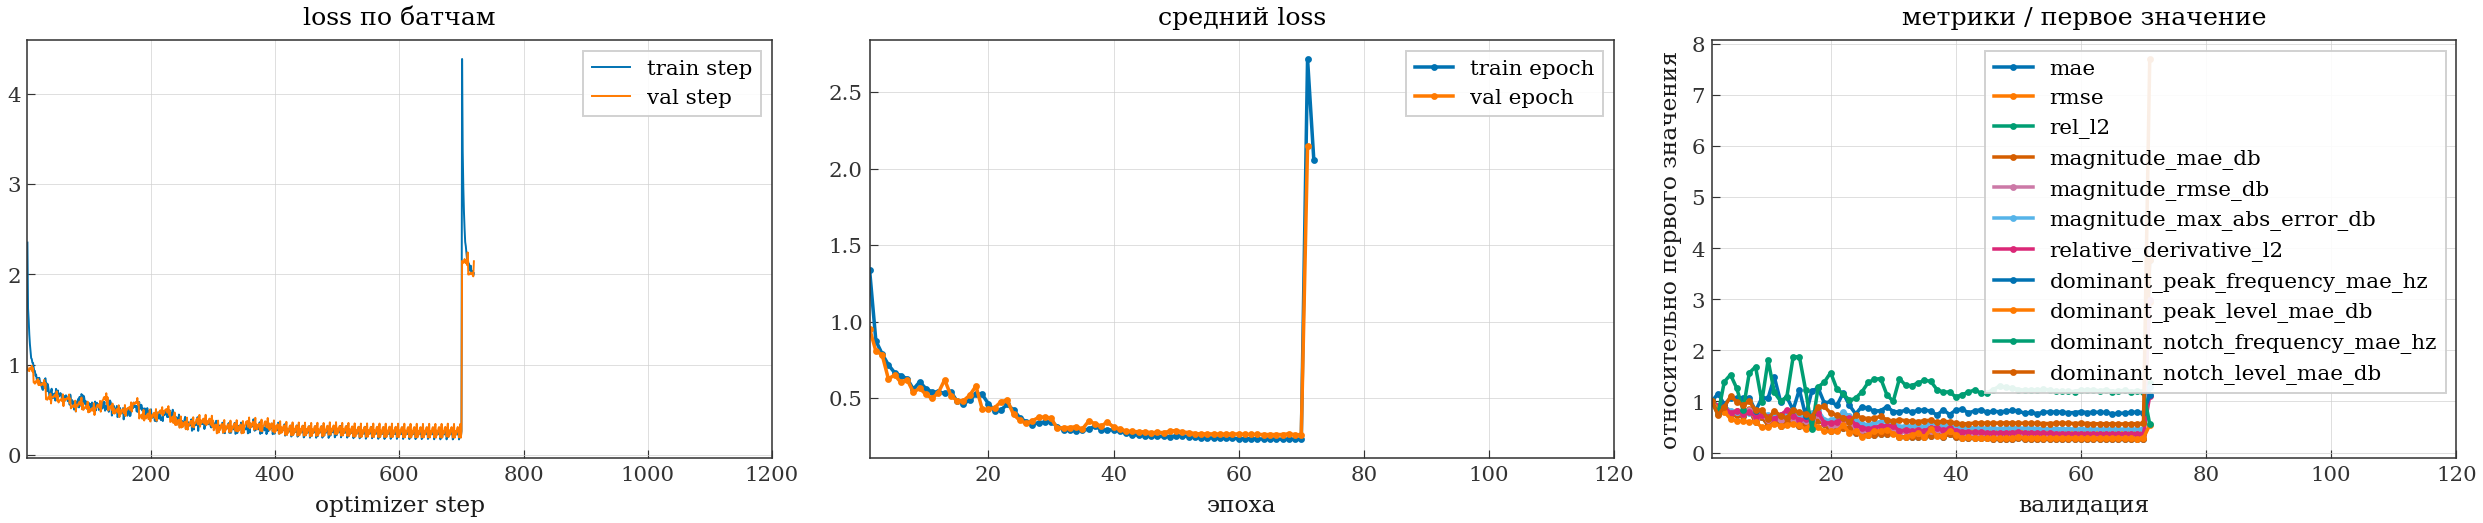

epoch 072/120 | train=2.05728 | val=2.01789 | lr=0.0002


KeyboardInterrupt: 

In [41]:
run_hole_finetune = False
if globals().get("run_hole_finetune", False):
    cleanup_training_memory()

    hole_finetune_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_hole_db"
    source_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_db"
    source_checkpoint_path = Path("checkpoints") / f"{source_checkpoint_name}_best.pt"

    hole_finetune_epochs = 50
    hole_finetune_steps_per_epoch = steps_per_epoch
    hole_finetune_val_steps = val_steps
    hole_finetune_batch_size = batch_size
    hole_finetune_live_plot_every_steps = live_plot_every_steps
    hole_finetune_save_every_steps = None

    hole_finetune_train_config = StreamingGeometryDatasetConfig(
        geometry_kind="tube_with_hole",
        solver_config=solver_config,
        target_mode="db",
        seed=3_000_000,
    )

    hole_finetune_val_config = StreamingGeometryDatasetConfig(
        geometry_kind="tube_with_hole",
        solver_config=solver_config,
        target_mode="db",
        seed=4_000_000,
        max_samples=hole_finetune_batch_size * hole_finetune_val_steps,
    )

    hole_finetune_train_loader = make_streaming_dataloader(
        hole_finetune_train_config,
        hole_library,
        batch_size=hole_finetune_batch_size,
        num_workers=0,
    )

    print("hole_library geometry kinds:", list(hole_library.keys()))

    hole_finetune_val_loader = make_streaming_dataloader(
        hole_finetune_val_config,
        hole_library,
        batch_size=hole_finetune_batch_size,
        num_workers=0,
    )

    mamba_siren_dynamic_deformable_deeponet = TransferFunctionMambaSIRENDynamicDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        trunk_hidden_dim=128,
        trunk_hidden_layers=3,
        first_omega_0=10.0,
        hidden_omega_0=10.0,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
        max_offset=2.0,
        offset_hidden_channels=32,
        mamba_backend="minimal_mamba2",
        mamba_depth=1,
        mamba_expansion=2,
        mamba_kernel_size=4,
        mamba_d_state=32,
        mamba_headdim=32,
        mamba_chunk_size=64,
        dropout=0.0,
        residual_dot=True,
        warm_start_verbose=False,
    ).to(device)

    if source_checkpoint_path.exists():
        source_checkpoint = torch.load(
            source_checkpoint_path,
            map_location=device,
            weights_only=False,
        )
        utils.load_model_state(
            mamba_siren_dynamic_deformable_deeponet,
            utils.checkpoint_state_dict(source_checkpoint),
            strict=True,
        )
        resume_history = source_checkpoint.get("history") if isinstance(source_checkpoint, dict) else None
        print("loaded source checkpoint:", source_checkpoint_path)
    else:
        resume_history = None
        print("source checkpoint not found, training from scratch:", source_checkpoint_path)

    hole_finetune_optimizer = utils.make_optimizer(
        mamba_siren_dynamic_deformable_deeponet,
        lr=2e-4,
        weight_decay=1e-4,
    )

    hole_finetune_scheduler = utils.make_plateau_scheduler(
        hole_finetune_optimizer,
        factor=0.5,
        patience=3,
        min_lr=1e-7,
    )

    hole_finetune_history = utils.fit(
        mamba_siren_dynamic_deformable_deeponet,
        hole_finetune_optimizer,
        hole_finetune_train_loader,
        hole_finetune_val_loader,
        scheduler=hole_finetune_scheduler,
        criterion=criterion,
        batch_to_xy=deeponet_batch_to_xy,
        config=utils.TrainConfig(
            epochs=hole_finetune_epochs,
            steps_per_epoch=hole_finetune_steps_per_epoch,
            val_steps=hole_finetune_val_steps,
            device=device,
            show_progress=False,
            live_plot_every_steps=hole_finetune_live_plot_every_steps,
            grad_clip_norm=None,
            checkpoint_name=hole_finetune_checkpoint_name,
            save_every_steps=hole_finetune_save_every_steps,
            validation_metrics=validation_metrics,
            scheduler_on="val_loss",
        ),
        resume_history=resume_history,
    )

    mamba_siren_dynamic_deformable_deeponet_hole_history = hole_finetune_history
    utils.plot_history(hole_finetune_history)

    utils.plot_single_model_preview(
        mamba_siren_dynamic_deformable_deeponet,
        deeponet_batch_to_xy,
        "Mamba SIREN Dynamic Deformable DeepONet, hole fine-tuned",
        loader=hole_finetune_val_loader,
        device=device,
        sample_idx=preview_sample_idx,
    )

    print(
        "best hole checkpoint:",
        Path("checkpoints") / f"{hole_finetune_checkpoint_name}_best.pt",
    )
else:
    print("Hole fine-tuning skipped")


### Сравнение

skip MLP MSE baseline: checkpoint_name is None
skip FiLM DeepONet: checkpoint_name is None
skip Bilinear Fusion DeepONet: checkpoint_name is None
skip Attention Fusion DeepONet: checkpoint_name is None
skip SIREN DeepONet: checkpoint_name is None
skip Mamba Fusion DeepONet: checkpoint_name is None
skip Dynamic DeepONet: checkpoint_name is None
skip Deformable DeepONet: checkpoint_name is None
skip Mamba SIREN Dynamic Deformable DeepONet: checkpoint_name is None
mlp: loaded checkpoint checkpoints/mlp_db_best.pt
mlp: loaded training history from checkpoint
fno: loaded checkpoint checkpoints/fno_db_best.pt
fno: loaded training history from checkpoint
deeponet: loaded checkpoint checkpoints/deeponet_db_best.pt
deeponet: loaded training history from checkpoint
mamba_operator: loaded checkpoint checkpoints/mamba_operator_db_best.pt
mamba_operator: loaded training history from checkpoint
MLP                          MAE dB:   2.2301 | RMSE dB:   2.5953
FNO                          MAE dB:   1

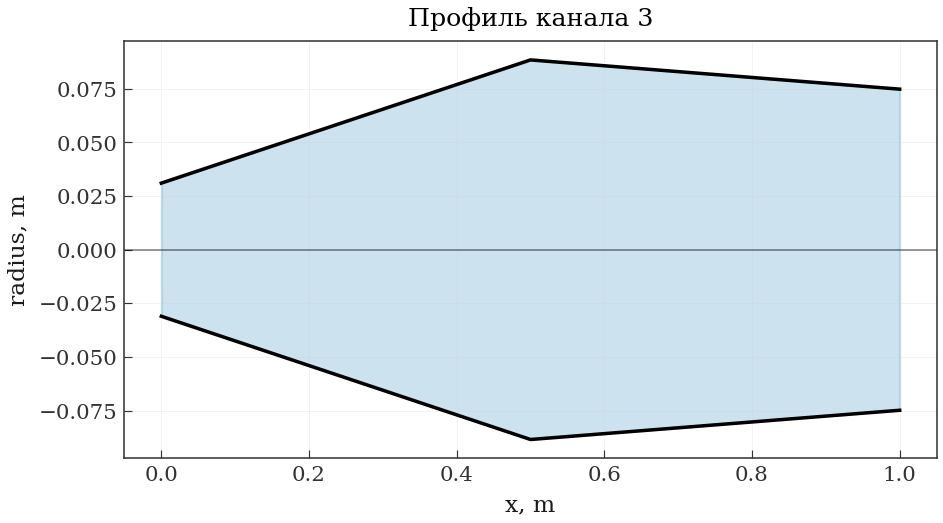

saved figure: article/images/mlp_fno_deep_mamba.png


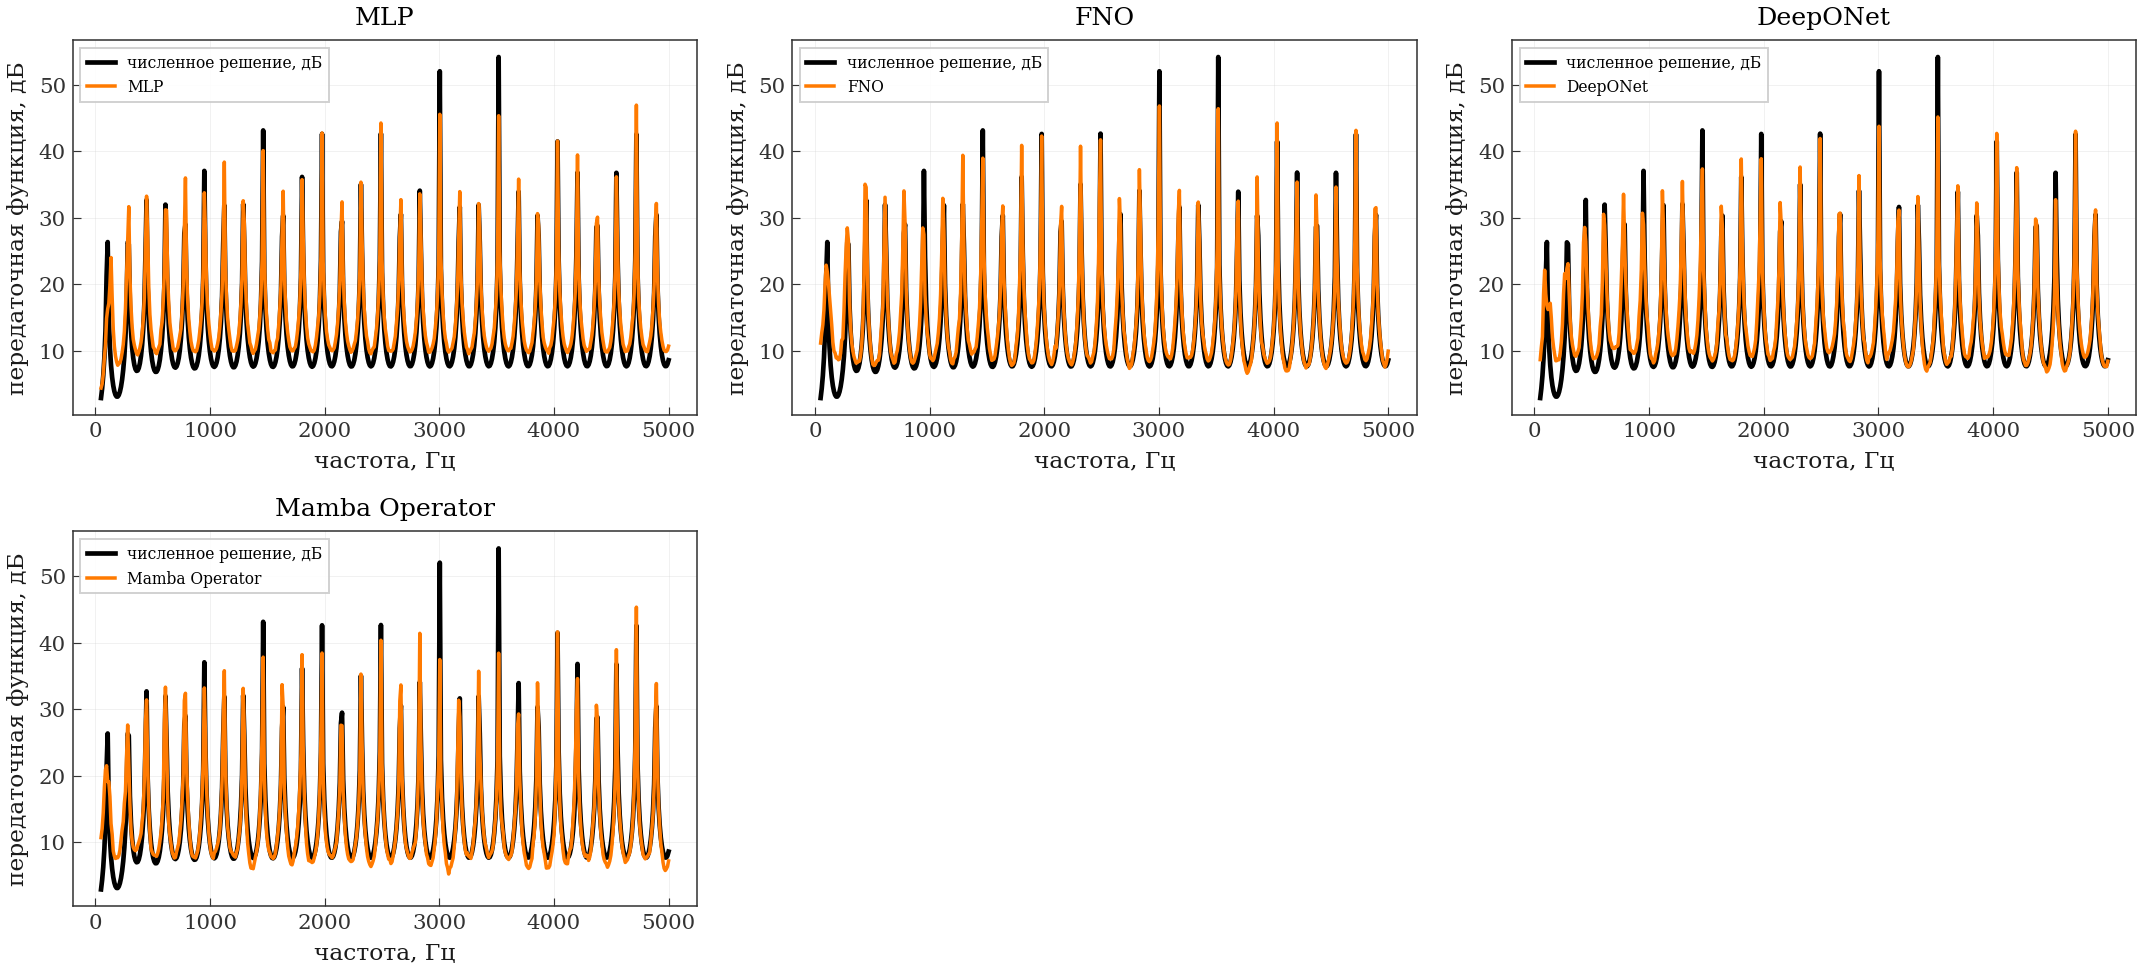

In [16]:
# Set any checkpoint name to None to remove this model from comparison.

mlp_mse_checkpoint_name = None
mlp_checkpoint_name = None
fno_checkpoint_name = None
deeponet_checkpoint_name = None
film_deeponet_checkpoint_name = None
bilinear_fusion_deeponet_checkpoint_name = None
attention_fusion_deeponet_checkpoint_name = None
siren_deeponet_checkpoint_name = None
mamba_fusion_deeponet_checkpoint_name = None
mamba_siren_dynamic_deformable_deeponet_checkpoint_name = None
dynamic_deeponet_checkpoint_name = None
deformable_deeponet_checkpoint_name = None
mamba_operator_checkpoint_name = None


# mlp_mse_checkpoint_name = "mlp_mse_db"
mlp_checkpoint_name = "mlp_db"
fno_checkpoint_name = "fno_db"
deeponet_checkpoint_name = "deeponet_db"
# film_deeponet_checkpoint_name = "film_deeponet_db"
# bilinear_fusion_deeponet_checkpoint_name = "bilinear_fusion_deeponet_db"
# attention_fusion_deeponet_checkpoint_name = "attention_fusion_deeponet_db"
# siren_deeponet_checkpoint_name = "siren_deeponet_db"
# mamba_fusion_deeponet_checkpoint_name = "mamba_fusion_deeponet_db"
# dynamic_deeponet_checkpoint_name = "dynamic_deeponet_new_db"
# deformable_deeponet_checkpoint_name = "deformable_deeponet_db"
mamba_operator_checkpoint_name = "mamba_operator_db"
# mamba_siren_dynamic_deformable_deeponet_checkpoint_name = "mamba_siren_dynamic_deformable_deeponet_db"


comparison_seed = 100_000
comparison_sample_idx = 3
comparison_image_title = "mlp fno deep mamba"
comparison_batch = validation_preview_batch()

def make_mlp_for_comparison():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_mlp_mse_for_comparison():
    return ProfileMLP(
        n_profile_points=n_profile_points,
        in_channels=2,
        n_frequencies=n_frequencies,
        hidden_dim=512,
        depth=4,
        dropout=0.05,
        out_channels=1,
    )


def make_fno_for_comparison():
    return TransferFunctionFNO(
        n_modes=32,
        hidden_channels=96,
        latent_dim=256,
        pooling_bins=16,
        frequency_bands=16,
        out_channels=1,
    )


def make_deeponet_for_comparison():
    return TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_film_deeponet_for_comparison():
    return TransferFunctionFiLMDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    )


def make_bilinear_fusion_deeponet_for_comparison():
    return TransferFunctionBilinearFusionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        fusion_rank=128,
        out_channels=1,
        residual_dot=True,
    )


def make_attention_fusion_deeponet_for_comparison():
    return TransferFunctionAttentionFusionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        trunk_hidden_dim=128,
        attention_dim=64,
        memory_tokens=8,
        out_channels=1,
        dropout=0.0,
        residual_dot=True,
    )


def make_siren_deeponet_for_comparison():
    return TransferFunctionSIRENDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        trunk_hidden_dim=128,
        trunk_hidden_layers=3,
        first_omega_0=10.0,
        hidden_omega_0=10.0,
        out_channels=1,
    )


def make_mamba_fusion_deeponet_for_comparison():
    return TransferFunctionMambaFusionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        mamba_backend="minimal_mamba2",
        mamba_depth=1,
        mamba_expansion=2,
        mamba_kernel_size=4,
        mamba_d_state=32,
        mamba_headdim=32,
        mamba_chunk_size=64,
        dropout=0.0,
        residual_dot=True,
    )


def make_mamba_siren_dynamic_deformable_deeponet_for_comparison():
    return TransferFunctionMambaSIRENDynamicDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        trunk_hidden_dim=128,
        trunk_hidden_layers=3,
        first_omega_0=10.0,
        hidden_omega_0=10.0,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
        max_offset=2.0,
        offset_hidden_channels=32,
        mamba_backend="minimal_mamba2",
        mamba_depth=1,
        mamba_expansion=2,
        mamba_kernel_size=4,
        mamba_d_state=32,
        mamba_headdim=32,
        mamba_chunk_size=64,
        dropout=0.0,
        residual_dot=True,
    )


def make_mamba_operator_for_comparison():
    return TransferFunctionMambaOperator(
        in_channels=1,
        d_model=32,
        hidden_channels=64,
        frequency_bands=16,
        frequency_hidden_dim=128,
        mamba_backend="minimal_mamba2",
        mamba_depth=2,
        mamba_expansion=2,
        mamba_kernel_size=4,
        mamba_d_state=16,
        mamba_headdim=32,
        mamba_chunk_size=32,
        dropout=0.0,
        out_channels=1,
        frequency_chunk_size=8,
    )


def make_dynamic_deeponet_for_comparison():
    return TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    )


def make_deformable_deeponet_for_comparison():
    return TransferFunctionDeformableDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        max_offset=2.0,
        offset_hidden_channels=32,
    )



model_specs = {
    "MLP": {
        "variable_name": "mlp",
        "checkpoint_name": mlp_checkpoint_name,
        "factory": make_mlp_for_comparison,
        "history_name": "mlp_history",
        "batch_to_xy": mlp_batch_to_xy,
    },
    "MLP MSE baseline": {
        "variable_name": "mlp_mse",
        "checkpoint_name": mlp_mse_checkpoint_name,
        "factory": make_mlp_mse_for_comparison,
        "history_name": "mlp_mse_history",
        "batch_to_xy": mlp_batch_to_xy,
    },
    "FNO": {
        "variable_name": "fno",
        "checkpoint_name": fno_checkpoint_name,
        "factory": make_fno_for_comparison,
        "history_name": "fno_history",
        "batch_to_xy": fno_batch_to_xy,
    },
    "DeepONet": {
        "variable_name": "deeponet",
        "checkpoint_name": deeponet_checkpoint_name,
        "factory": make_deeponet_for_comparison,
        "history_name": "deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "FiLM DeepONet": {
        "variable_name": "film_deeponet",
        "checkpoint_name": film_deeponet_checkpoint_name,
        "factory": make_film_deeponet_for_comparison,
        "history_name": "film_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "Bilinear Fusion DeepONet": {
        "variable_name": "bilinear_fusion_deeponet",
        "checkpoint_name": bilinear_fusion_deeponet_checkpoint_name,
        "factory": make_bilinear_fusion_deeponet_for_comparison,
        "history_name": "bilinear_fusion_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "Attention Fusion DeepONet": {
        "variable_name": "attention_fusion_deeponet",
        "checkpoint_name": attention_fusion_deeponet_checkpoint_name,
        "factory": make_attention_fusion_deeponet_for_comparison,
        "history_name": "attention_fusion_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "SIREN DeepONet": {
        "variable_name": "siren_deeponet",
        "checkpoint_name": siren_deeponet_checkpoint_name,
        "factory": make_siren_deeponet_for_comparison,
        "history_name": "siren_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "Mamba Fusion DeepONet": {
        "variable_name": "mamba_fusion_deeponet",
        "checkpoint_name": mamba_fusion_deeponet_checkpoint_name,
        "factory": make_mamba_fusion_deeponet_for_comparison,
        "history_name": "mamba_fusion_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },

    "Mamba Operator": {
        "variable_name": "mamba_operator",
        "checkpoint_name": mamba_operator_checkpoint_name,
        "factory": make_mamba_operator_for_comparison,
        "history_name": "mamba_operator_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "Dynamic DeepONet": {
        "variable_name": "dynamic_deeponet",
        "checkpoint_name": dynamic_deeponet_checkpoint_name,
        "factory": make_dynamic_deeponet_for_comparison,
        "history_name": "dynamic_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
    "Deformable DeepONet": {
        "variable_name": "deformable_deeponet",
        "checkpoint_name": deformable_deeponet_checkpoint_name,
        "factory": make_deformable_deeponet_for_comparison,
        "history_name": "deformable_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },

    "Mamba SIREN Dynamic Deformable DeepONet": {
        "variable_name": "mamba_siren_dynamic_deformable_deeponet",
        "checkpoint_name": mamba_siren_dynamic_deformable_deeponet_checkpoint_name,
        "factory": make_mamba_siren_dynamic_deformable_deeponet_for_comparison,
        "history_name": "mamba_siren_dynamic_deformable_deeponet_history",
        "batch_to_xy": deeponet_batch_to_xy,
    },
}

comparison_result = utils.compare_forward_models(
    globals(),
    model_specs,
    batch=comparison_batch,
    seed=comparison_seed,
    target_batch_to_xy=mlp_batch_to_xy,
    sample_idx=comparison_sample_idx,
    device=device,
    image_title=comparison_image_title,
    output_dir="article/images",
    style=True,
    save=True,
    show=True,
    hide_titles=False,
    overwrite=True,
)

predictions = comparison_result["predictions"]
target = comparison_result["target"]


skip MLP MSE baseline: checkpoint_name is None
skip FiLM DeepONet: checkpoint_name is None
skip Bilinear Fusion DeepONet: checkpoint_name is None
skip Attention Fusion DeepONet: checkpoint_name is None
skip SIREN DeepONet: checkpoint_name is None
skip Mamba Fusion DeepONet: checkpoint_name is None
skip Dynamic DeepONet: checkpoint_name is None
skip Deformable DeepONet: checkpoint_name is None
skip Mamba SIREN Dynamic Deformable DeepONet: checkpoint_name is None
=== Loaded history lengths ===
MLP                          train= 40 val= 40 train_steps= 400 val_steps= 400
FNO                          train= 40 val= 40 train_steps= 400 val_steps= 400
DeepONet                     train= 40 val= 40 train_steps= 400 val_steps= 400
Mamba Operator               train= 40 val= 40 train_steps= 400 val_steps= 400
saved figure: article/images/функции_потерь_mlp_fno_deep_mamba.png


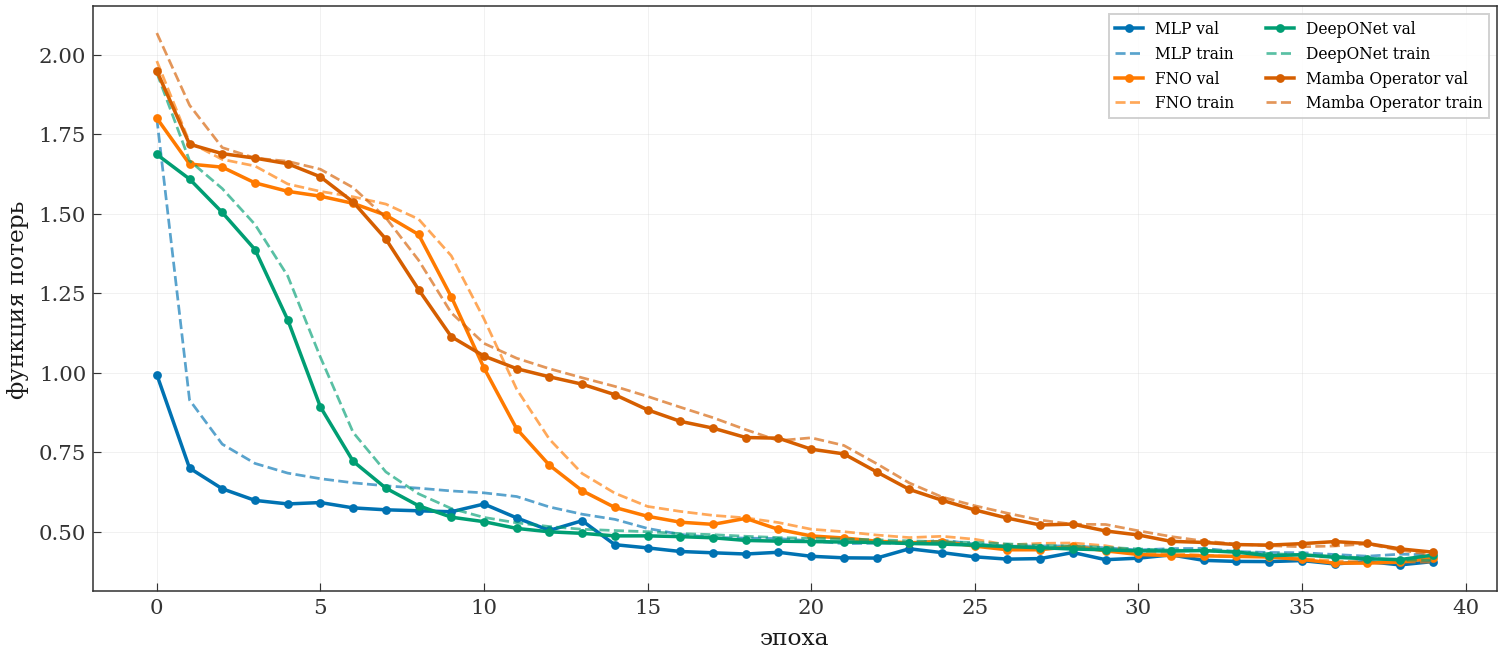

=== Best losses ===
MLP                          best train loss: 0.42337466180324557 | best val loss: 0.3960178107023239
FNO                          best train loss: 0.40458216071128844 | best val loss: 0.4014952123165131
DeepONet                     best train loss: 0.41063567996025085 | best val loss: 0.41254175901412965
Mamba Operator               best train loss: 0.42797209322452545 | best val loss: 0.43609278500080106


In [18]:
history_comparison = utils.compare_training_histories(
    globals(),
    model_specs,
    image_title="Функции потерь mlp fno deep mamba",
    output_dir="article/images",
    style=True,
    save=True,
    show=True,
    hide_titles=True,
    overwrite=True,
    yscale="linear",
    curves=("val", "train"),
)

skip MLP MSE baseline: checkpoint_name is None
skip FiLM DeepONet: checkpoint_name is None
skip Bilinear Fusion DeepONet: checkpoint_name is None
skip Attention Fusion DeepONet: checkpoint_name is None
skip SIREN DeepONet: checkpoint_name is None
skip Mamba Fusion DeepONet: checkpoint_name is None
skip Dynamic DeepONet: checkpoint_name is None
skip Deformable DeepONet: checkpoint_name is None
skip Mamba SIREN Dynamic Deformable DeepONet: checkpoint_name is None


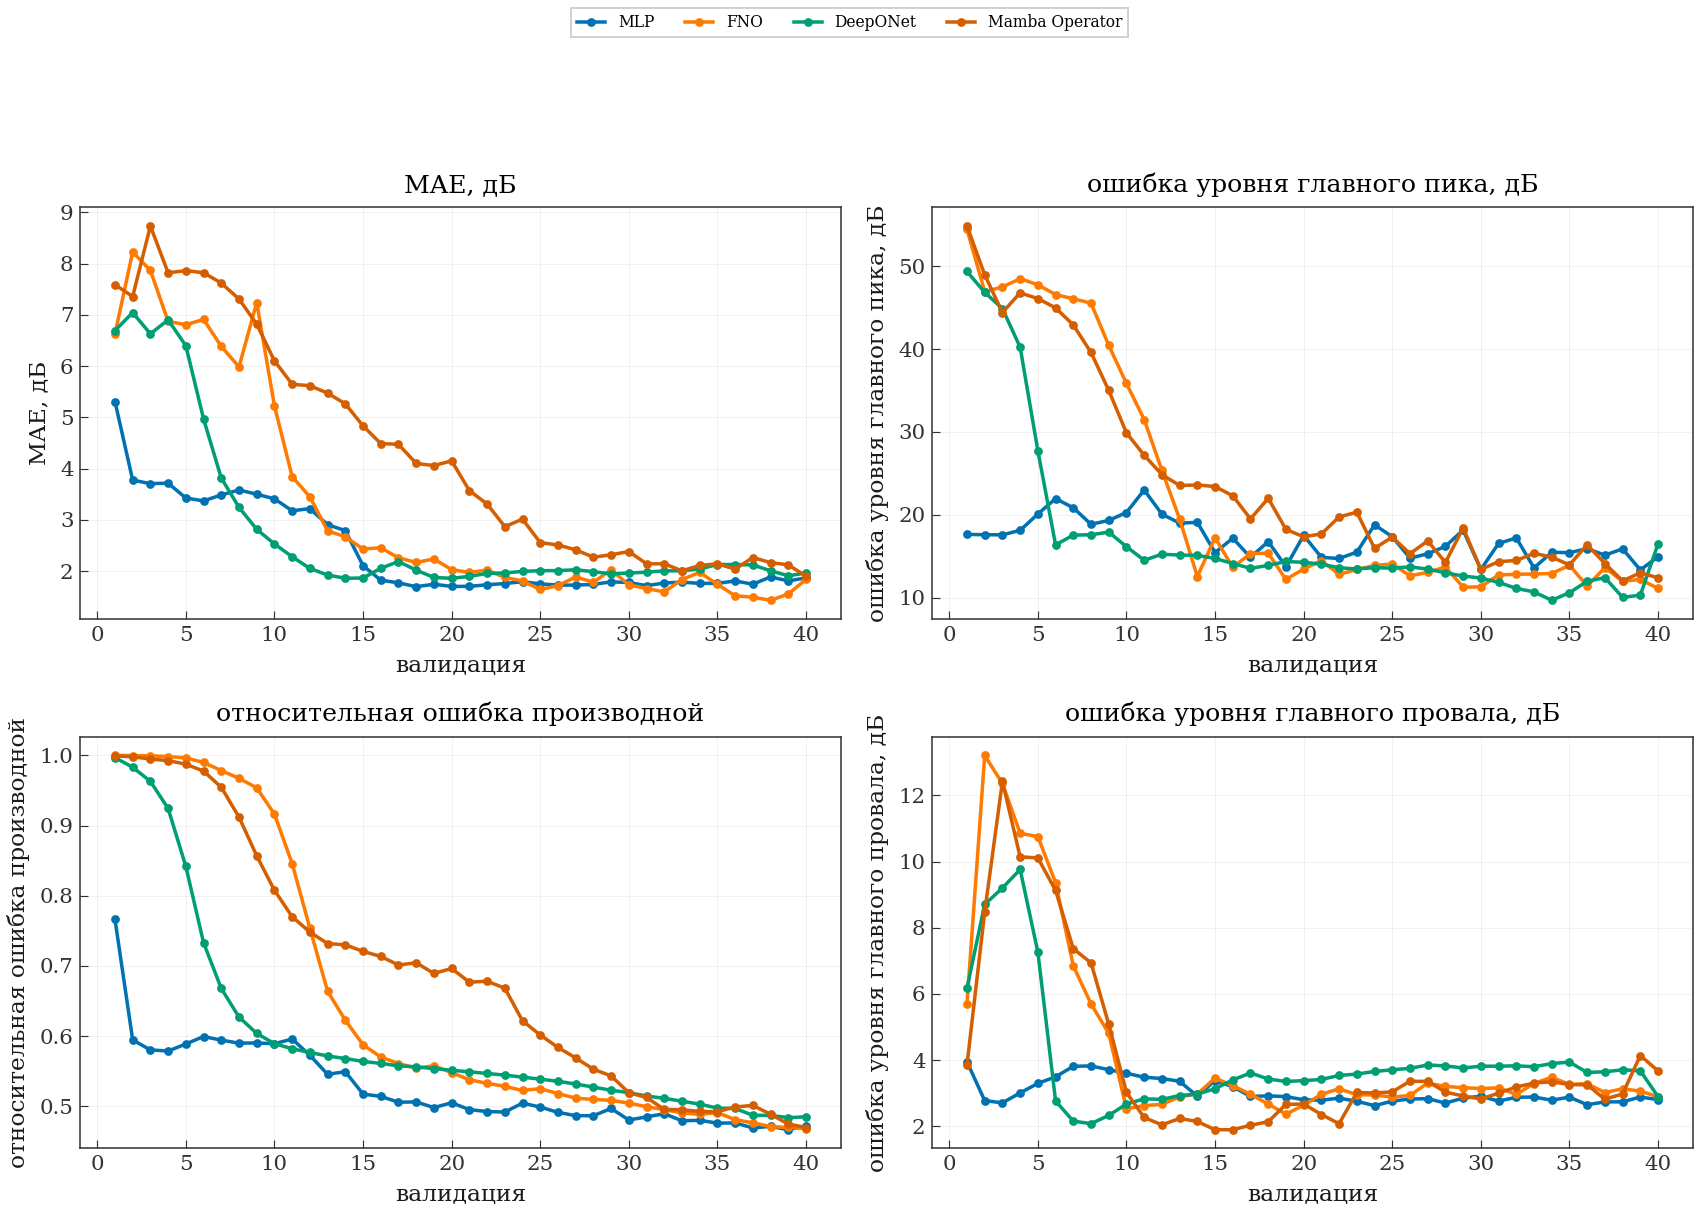

=== Лучшие значения MAE, дБ (min) ===
модель                       |  лучшее значение |  валидация
-----------------------------------------------------------
FNO                          |        1.42985 |         38
MLP                          |        1.69501 |         18
DeepONet                     |        1.85856 |         20
Mamba Operator               |        1.89966 |         40
=== Лучшие значения ошибка уровня главного пика, дБ (min) ===
модель                       |  лучшее значение |  валидация
-----------------------------------------------------------
DeepONet                     |        9.68496 |         34
FNO                          |        11.1108 |         40
Mamba Operator               |        12.0219 |         38
MLP                          |        13.3461 |         39
=== Лучшие значения относительная ошибка производной (min) ===
модель                       |  лучшее значение |  валидация
-----------------------------------------------------------
ML

In [19]:
top_metric_names = [
    "mae",
    "dominant_peak_level_mae_db",
    "relative_derivative_l2",
    "dominant_notch_level_mae_db"
]

metric_comparison = utils.compare_training_metrics(
    globals(),
    model_specs,
    metric_names=top_metric_names,
    image_title="Метрики mlp fno deep mamba",
    output_dir="article/images",
    style=True,
    save=False,
    show=True,
    hide_titles=True,
    overwrite=True,
    yscale=None,
    best_mode="min",
)

### Неожиданная геометрия

In [ ]:
if globals().get("run_unexpected_geometry_check", False):
    mlp_mse_checkpoint_name = globals().get("mlp_mse_checkpoint_name", "mlp_mse_db")
    # Cell 12: unexpected geometry check

    unexpected_geometry_kind = "tube_with_hole"  # "tube_with_hole" or "sharp_bottleneck"



    def make_mlp_for_unexpected():
        return ProfileMLP(
            n_profile_points=n_profile_points,
            in_channels=2,
            n_frequencies=n_frequencies,
            hidden_dim=512,
            depth=4,
            dropout=0.05,
            out_channels=1,
        )


    def make_mlp_mse_for_unexpected():
        return ProfileMLP(
            n_profile_points=n_profile_points,
            in_channels=2,
            n_frequencies=n_frequencies,
            hidden_dim=512,
            depth=4,
            dropout=0.05,
            out_channels=1,
        )


    def make_fno_for_unexpected():
        return TransferFunctionFNO(
            n_modes=32,
            hidden_channels=96,
            latent_dim=256,
            pooling_bins=16,
            frequency_bands=16,
            out_channels=1,
        )


    def make_deeponet_for_unexpected():
        return TransferFunctionDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
        )


    def make_dynamic_deeponet_for_unexpected():
        return TransferFunctionDynamicDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            n_experts=4,
            routing_hidden_dim=32,
            temperature=1.0,
        )


    def make_deformable_deeponet_for_unexpected():
        return TransferFunctionDeformableDeepONet(
            in_channels=1,
            hidden_channels=64,
            basis_dim=128,
            pooling_bins=16,
            frequency_bands=16,
            trunk_hidden_dim=128,
            out_channels=1,
            max_offset=2.0,
            offset_hidden_channels=32,
        )


    unexpected_geometry = utils.make_unexpected_geometry(unexpected_geometry_kind)
    unexpected_batch = utils.make_single_geometry_batch(
        unexpected_geometry,
        solver_config,
        geometry_kind=unexpected_geometry_kind,
    )

    unexpected_models = [
        ("MLP", utils.get_or_load_model(globals(), variable_name="mlp", checkpoint_name=mlp_checkpoint_name, factory=make_mlp_for_unexpected, device=device, verbose=False)[0], mlp_batch_to_xy),
        ("MLP MSE", utils.get_or_load_model(globals(), variable_name="mlp_mse", checkpoint_name=mlp_mse_checkpoint_name, factory=make_mlp_mse_for_unexpected, device=device, verbose=False)[0], mlp_batch_to_xy),
        ("FNO", utils.get_or_load_model(globals(), variable_name="fno", checkpoint_name=fno_checkpoint_name, factory=make_fno_for_unexpected, device=device, verbose=False)[0], fno_batch_to_xy),
        (
            "DeepONet",
            utils.get_or_load_model(globals(), variable_name="deeponet", checkpoint_name=deeponet_checkpoint_name, factory=make_deeponet_for_unexpected, device=device, verbose=False)[0],
            deeponet_batch_to_xy,
        ),
        (
            "Dynamic DeepONet",
            utils.get_or_load_model(globals(), variable_name="dynamic_deeponet", checkpoint_name=dynamic_deeponet_checkpoint_name, factory=make_dynamic_deeponet_for_unexpected, device=device, verbose=False)[0],
            deeponet_batch_to_xy,
        ),
        (
            "Deformable DeepONet",
            utils.get_or_load_model(globals(), variable_name="deformable_deeponet", checkpoint_name=deformable_deeponet_checkpoint_name, factory=make_deformable_deeponet_for_unexpected, device=device, verbose=False)[0],
            deeponet_batch_to_xy,
        ),
    ]

    _, unexpected_target = mlp_batch_to_xy(unexpected_batch, torch.device(device))
    unexpected_target = unexpected_target.detach().cpu()

    print("unexpected geometry:", unexpected_geometry_kind)
    print("target shape:", tuple(unexpected_target.shape))

    # Draw geometry once.
    plt.figure(figsize=(9, 3.5))
    ax = plt.gca()
    plot_batch_geometry(
        unexpected_batch,
        0,
        ax,
        title=f"Unexpected geometry: {unexpected_geometry_kind}",
    )
    plt.tight_layout()
    plt.show()

    # Separate prediction plot for each available model.
    unexpected_predictions = {}
    for name, model, batch_to_xy in unexpected_models:
        if model is None:
            continue

        prediction, _ = predict_on_batch(model, batch_to_xy, unexpected_batch)
        unexpected_predictions[name] = prediction
        plot_model_prediction_on_channel(
            unexpected_batch,
            prediction,
            unexpected_target,
            f"{name} on {unexpected_geometry_kind}",
            sample_idx=0,
        )

    # Combined plot for quick comparison.
    if unexpected_predictions:
        freq = unexpected_batch["frequencies_hz"][0].detach().cpu()
        y = unexpected_target[0]

        plt.figure(figsize=(12, 5))
        plt.plot(freq, y, color="black", linewidth=2.4, label="target cone dB")
        for name, prediction in unexpected_predictions.items():
            plt.plot(freq, prediction[0], linewidth=1.8, alpha=0.85, label=name)

        plt.xlabel("Frequency, Hz")
        plt.ylabel("Transfer function, dB")
        plt.title(f"Unexpected geometry comparison: {unexpected_geometry_kind}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        print("=== Unexpected geometry metrics ===")
        for name, prediction in unexpected_predictions.items():
            pred = prediction[0]
            mae = torch.mean(torch.abs(pred - y)).item()
            rmse = torch.sqrt(torch.mean((pred - y) ** 2)).item()
            print(f"{name:8s} MAE dB: {mae:8.4f} | RMSE dB: {rmse:8.4f}")
    else:
        print("No trained models are available for unexpected-geometry check.")
else:
    print("Unexpected geometry check skipped")


## Масштабирование

In [ ]:
if globals().get("run_scaling_check", False):
    import numpy as np
    import torch
    import matplotlib.pyplot as plt

    import vt_all_solvers_wrapper as vt
    import utils


    # ----------------------------
    # 1) Choose trained model
    # ----------------------------
    checkpoint_path = Path("checkpoints") / "deeponet_db_best.pt"
    model = TransferFunctionDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
    ).to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    utils.load_model_state(model, checkpoint["model_state"], strict=True)
    model.eval()

    batch_to_xy = deeponet_batch_to_xy


    # ----------------------------
    # 2) Make original 4 m geometry
    # ----------------------------

    original_length_m = 4.0
    scaled_length_m = 1.0
    scale_factor = scaled_length_m / original_length_m  # 0.25

    x_norm = np.linspace(0.0, 1.0, 13)

    # Any profile shape. This is area profile for the 4 m original channel.
    original_area_m2 = np.array(
        [
            3.0e-4,
            3.5e-4,
            5.0e-4,
            8.0e-4,
            1.2e-3,
            7.0e-4,
            4.0e-4,
            5.5e-4,
            9.0e-4,
            6.0e-4,
            4.5e-4,
            3.5e-4,
            3.0e-4,
        ],
        dtype=float,
    )

    original_geometry = vt.ExplicitGeometry(
        x_m=(original_length_m * x_norm).tolist(),
        area_m2=original_area_m2.tolist(),
    )

    # Full geometric scaling:
    # x -> s * x
    # area -> s^2 * area
    scaled_geometry = vt.ExplicitGeometry(
        x_m=(scale_factor * np.asarray(original_geometry.x_m)).tolist(),
        area_m2=((scale_factor ** 2) * np.asarray(original_geometry.area_m2)).tolist(),
    )


    # ----------------------------
    # 3) Numerical solution on original channel
    # ----------------------------

    # The original frequency range must map into the model frequency range.
    # If model was trained on 50..5000 Hz and scale_factor=0.25,
    # original frequencies 12.5..1250 Hz map to scaled frequencies 50..5000 Hz.
    original_solver_config = vt.SolverConfig(
        solver="cone",
        sections=100,
        points=n_frequencies,
        f_min_hz=scale_factor * solver_config.f_min_hz,
        f_max_hz=scale_factor * solver_config.f_max_hz,
        grid="linear",
        beta_loss_np_per_m=0.0,
    )

    original_result = vt.solve(
        original_geometry,
        config=original_solver_config,
    )

    freq_original = np.asarray(original_result.frequencies_hz, dtype=float)
    target_original_db = 20.0 * np.log10(
        np.maximum(np.asarray(original_result.magnitude, dtype=float), 1e-12)
    )


    # ----------------------------
    # 4) Neural prediction on scaled channel
    # ----------------------------

    freq_scaled = freq_original / scale_factor

    x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(scaled_geometry)

    scaled_batch = {
        "target": torch.zeros(1, len(freq_scaled), dtype=torch.float32),
        "frequencies_hz": torch.tensor(freq_scaled, dtype=torch.float32).unsqueeze(0),
        "geometry": {
            "x_m": torch.tensor([x_m], dtype=torch.float32),
            "area_m2": torch.tensor([area_m2], dtype=torch.float32),
            "segment_lengths_m": torch.tensor([segment_lengths_m], dtype=torch.float32),
            "node_count": torch.tensor([len(x_m)], dtype=torch.int64),
            "segment_count": torch.tensor([len(segment_lengths_m)], dtype=torch.int64),
        },
    }

    with torch.no_grad():
        prediction_scaled, _ = utils.predict(
            model,
            [scaled_batch],
            batch_to_xy=batch_to_xy,
            device=device,
            show_progress=False,
        )

    pred_original_db = prediction_scaled[0].detach().cpu().numpy()


    # ----------------------------
    # 5) Plot comparison
    # ----------------------------

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    vt.plot_geometry(
        original_geometry,
        mode="symmetric",
        equal_aspect=False,
        linewidth=1.5,
        ax=axes[0],
        title=f"Original geometry, L={original_length_m:g} m",
    )
    axes[0].grid(True, alpha=0.3)

    vt.plot_geometry(
        scaled_geometry,
        mode="symmetric",
        equal_aspect=False,
        linewidth=1.5,
        ax=axes[1],
        title=f"Scaled geometry, L={scaled_length_m:g} m",
    )
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(freq_original, target_original_db, linewidth=2.2, color="black", label="target cone, original")
    axes[2].plot(freq_original, pred_original_db, linewidth=1.8, label="NN on scaled geometry, frequency stretched back")
    axes[2].set_xlabel("Original frequency, Hz")
    axes[2].set_ylabel("Transfer function, dB")
    axes[2].set_title("Original numerical solution vs scaled NN prediction")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    mae = np.mean(np.abs(pred_original_db - target_original_db))
    rmse = np.sqrt(np.mean((pred_original_db - target_original_db) ** 2))

    print("scale_factor:", scale_factor)
    print("original frequency range:", freq_original[0], "to", freq_original[-1], "Hz")
    print("scaled model frequency range:", freq_scaled[0], "to", freq_scaled[-1], "Hz")
    print("MAE dB:", mae)
    print("RMSE dB:", rmse)
else:
    print("Scaling check skipped")


## Чувствителность к геометрии

In [ ]:
if globals().get("run_geometry_sensitivity_check", False):
    import torch

    # Choose model and adapter.
    model = deeponet                  # fno / deeponet / dynamic_deeponet / deformable_deeponet
    batch_to_xy = fno_batch_to_xy # fno_batch_to_xy or deeponet_batch_to_xy

    model = model.to(device)
    model.eval()

    batch = next(iter(val_loader))

    inputs, target = batch_to_xy(batch, torch.device(device))

    if isinstance(inputs, tuple):
        area, kappa = inputs
    else:
        raise TypeError(
            "This sensitivity block expects an operator model with inputs = (area, kappa). "
            "Use FNO / DeepONet / Dynamic DeepONet / Deformable DeepONet."
        )

    with torch.no_grad():
        prediction = model(area, kappa)

        permutation = torch.randperm(
            area.shape[0],
            device=area.device,
        )

        shuffled_prediction = model(
            area[permutation],
            kappa,
        )

    sensitivity_abs = torch.mean(
        torch.abs(prediction - shuffled_prediction)
    )

    sensitivity_rmse = torch.sqrt(
        torch.mean((prediction - shuffled_prediction) ** 2)
    )

    output_scale = torch.mean(torch.abs(prediction)).clamp_min(1e-12)
    relative_sensitivity = sensitivity_abs / output_scale

    print("Permutation:", permutation.detach().cpu().tolist())
    print("Geometry sensitivity MAE:", sensitivity_abs.item())
    print("Geometry sensitivity RMSE:", sensitivity_rmse.item())
    print("Relative geometry sensitivity:", relative_sensitivity.item())
else:
    print("Geometry sensitivity check skipped")


In [ ]:
if globals().get("run_frequency_grid_check", False):
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    from pathlib import Path

    import vt_all_solvers_wrapper as vt
    import utils
    from models.deep import TransferFunctionDeepONet

    device = "cuda" if torch.cuda.is_available() else "cpu"


    sample_idx = 0

    new_n_frequencies = 512
    new_f_min_hz = solver_config.f_min_hz
    new_f_max_hz = solver_config.f_max_hz


    deeponet_checkpoint_name = "dynamic_deeponet_new_db"

    model = TransferFunctionDynamicDeepONet(
        in_channels=1,
        hidden_channels=64,
        basis_dim=128,
        pooling_bins=16,
        frequency_bands=16,
        trunk_hidden_dim=128,
        out_channels=1,
        n_experts=4,
        routing_hidden_dim=32,
        temperature=1.0,
    ).to(device)

    checkpoint_path = Path("checkpoints") / f"{deeponet_checkpoint_name}_best.pt"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    utils.load_model_state(model, utils.checkpoint_state_dict(checkpoint), strict=True)
    model.eval()

    batch = next(iter(val_loader))

    x_default, target_default = deeponet_batch_to_xy(
        batch,
        torch.device(device),
    )
    area_default, kappa_default = x_default

    if sample_idx < 0 or sample_idx >= area_default.shape[0]:
        raise IndexError(
            f"sample_idx={sample_idx} is outside batch size {area_default.shape[0]}"
        )

    area_one = area_default[sample_idx : sample_idx + 1].to(device)
    kappa_default_one = kappa_default[sample_idx : sample_idx + 1].to(device)

    freq_default = batch["frequencies_hz"][sample_idx].detach().cpu().numpy()
    target_default_np = target_default[sample_idx].detach().cpu().numpy()

    geom = batch["geometry"]
    n = int(geom["node_count"][sample_idx])

    geometry = vt.ExplicitGeometry(
        x_m=geom["x_m"][sample_idx, :n].detach().cpu().tolist(),
        area_m2=geom["area_m2"][sample_idx, :n].detach().cpu().tolist(),
    )

    with torch.no_grad():
        pred_default = model(area_one, kappa_default_one)

    pred_default = pred_default[0].detach().cpu().numpy()

    freq_new_np = np.linspace(
        new_f_min_hz,
        new_f_max_hz,
        new_n_frequencies,
        dtype=np.float32,
    )

    kappa_new_np = (
        (freq_new_np - solver_config.f_min_hz)
        / (solver_config.f_max_hz - solver_config.f_min_hz)
    ).astype(np.float32)

    kappa_new = torch.from_numpy(kappa_new_np).view(1, -1, 1).to(device)

    with torch.no_grad():
        pred_new = model(area_one, kappa_new)

    pred_new = pred_new[0].detach().cpu().numpy()

    new_solver_config = vt.SolverConfig(
        solver=solver_config.solver,
        sections=solver_config.sections,
        points=new_n_frequencies,
        f_min_hz=new_f_min_hz,
        f_max_hz=new_f_max_hz,
        grid="linear",
        beta_loss_np_per_m=solver_config.beta_loss_np_per_m,
    )

    solver_result = vt.solve(
        geometry,
        new_solver_config,
    )

    freq_new_solver = np.asarray(solver_result.frequencies_hz, dtype=np.float32)
    H_new = np.asarray(solver_result.transfer_complex, dtype=np.complex64)
    target_new_db = 20.0 * np.log10(np.maximum(np.abs(H_new), 1e-12)).astype(np.float32)

    mae_default = np.mean(np.abs(pred_default - target_default_np))
    rmse_default = np.sqrt(np.mean((pred_default - target_default_np) ** 2))

    mae_new = np.mean(np.abs(pred_new - target_new_db))
    rmse_new = np.sqrt(np.mean((pred_new - target_new_db) ** 2))

    print("loaded:", checkpoint_path)
    print("checkpoint batch_size:", checkpoint.get("batch_size"))

    print("Default grid:")
    print("  n frequencies:", len(freq_default))
    print("  MAE dB:", mae_default)
    print("  RMSE dB:", rmse_default)

    print("New arbitrary grid:")
    print("  n frequencies:", len(freq_new_solver))
    print("  MAE dB:", mae_new)
    print("  RMSE dB:", rmse_new)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    vt.plot_geometry(
        geometry,
        mode="symmetric",
        ax=axes[0],
        title="Geometry",
        equal_aspect=False,
        linewidth=1.5,
    )

    axes[1].plot(freq_default, target_default_np, color="black", linewidth=2.0, label="target default dB")
    axes[1].plot(freq_default, pred_default, color="tab:blue", linewidth=1.5, label="DeepONet default grid")
    axes[1].set_title(f"Default grid: {len(freq_default)} frequencies")
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].set_ylabel("Transfer function, dB")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(freq_new_solver, target_new_db, color="black", linewidth=2.0, label="target solver dB")
    axes[2].plot(freq_new_np, pred_new, color="tab:orange", linewidth=1.5, label="DeepONet arbitrary grid")
    axes[2].set_title(f"Arbitrary grid: {len(freq_new_np)} frequencies")
    axes[2].set_xlabel("Frequency, Hz")
    axes[2].set_ylabel("Transfer function, dB")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Frequency grid check skipped")
